# UdyamFlow AI — Approval Intelligence Engine (ANN)

Multi-label Artificial Neural Network predicting required licenses/approvals for a proposed Punjab industrial business, given its profile (sector, investment, employees, power, land, water usage, etc.)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import warnings

warnings.filterwarnings('ignore')
print("Libraries loaded successfully")

Libraries loaded successfully


Libraries loaded successfully


## 1. Load Dataset

In [2]:
df = pd.read_csv('punjab_industrial_approval_dataset_large.csv')
print(df.shape)
df.head()

(8000, 23)


,business_id,district,sector,investment_lakhs,employee_count,power_requirement_kw,land_area_sqm,water_usage_kld,uses_hazardous_material,uses_boiler,...,factory_license,labour_registration,fire_noc,pollution_noc,environmental_clearance,fssai_license,boiler_license,explosives_license,electricity_noc,building_plan_approval
0,PB00001,Patiala,Agro-based,118.74,21,23.4,861.5,0.5,0,0,...,1,1,1,0,0,0,0,0,0,1
1,PB00002,Jalandhar,Leather Products,226.40,18,33.3,1246.4,19.2,1,0,...,1,0,1,1,0,0,0,0,1,1
2,PB00003,Sangrur,Agro-based,224.30,16,29.1,867.6,0.5,0,0,...,1,1,1,0,0,0,0,0,1,1
3,PB00004,Mohali,Plastic Products,1341.03,4,186.8,3792.8,13.5,1,0,...,0,0,1,1,0,0,0,1,1,0
4,PB00005,Jalandhar,Auto Components,1254.01,38,171.3,3607.4,7.7,0,0,...,1,1,1,0,0,0,0,0,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   business_id              8000 non-null   object 
 1   district                 8000 non-null   object 
 2   sector                   8000 non-null   object 
 3   investment_lakhs         8000 non-null   float64
 4   employee_count           8000 non-null   int64  
 5   power_requirement_kw     8000 non-null   float64
 6   land_area_sqm            8000 non-null   float64
 7   water_usage_kld          8000 non-null   float64
 8   uses_hazardous_material  8000 non-null   int64  
 9   uses_boiler              8000 non-null   int64  
 10  is_service_sector        8000 non-null   int64  
 11  trade_license            8000 non-null   int64  
 12  gst_registration         8000 non-null   int64  
 13  factory_license          8000 non-null   int64  
 14  labour_registration     

In [4]:
df.describe()

,investment_lakhs,employee_count,power_requirement_kw,land_area_sqm,water_usage_kld,uses_hazardous_material,uses_boiler,is_service_sector,trade_license,gst_registration,factory_license,labour_registration,fire_noc,pollution_noc,environmental_clearance,fssai_license,boiler_license,explosives_license,electricity_noc,building_plan_approval
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,703.821228,24.215500,107.066250,2149.437525,11.720625,0.259625,0.232875,0.052375,1.0,0.968125,0.639125,0.878875,0.933000,0.529250,0.167375,0.164250,0.232875,0.249500,0.769000,0.861875
std,922.951050,27.562325,139.177515,2794.970358,9.517582,0.438456,0.422690,0.222796,0.0,0.175678,0.480284,0.326293,0.250038,0.499175,0.373334,0.370525,0.422690,0.432751,0.421499,0.345053
min,2.930000,1.000000,2.000000,50.000000,0.500000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,188.930000,8.000000,29.500000,562.425000,2.900000,0.000000,0.000000,0.000000,1.0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,392.745000,16.000000,62.900000,1298.700000,10.300000,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,816.855000,29.000000,125.325000,2531.325000,18.525000,1.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6000.000000,422.000000,942.400000,19035.500000,47.600000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Define Features (X) and Multi-Label Targets (y)

In [5]:
feature_cols = [
    'district', 'sector', 'investment_lakhs', 'employee_count',
    'power_requirement_kw', 'land_area_sqm', 'water_usage_kld',
    'uses_hazardous_material', 'uses_boiler', 'is_service_sector'
]

target_cols = [
    'trade_license', 'gst_registration', 'factory_license', 'labour_registration',
    'fire_noc', 'pollution_noc', 'environmental_clearance', 'fssai_license',
    'boiler_license', 'explosives_license', 'electricity_noc', 'building_plan_approval'
]

X = df[feature_cols]
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8000, 10)
y shape: (8000, 12)


## 3. Check Target (Label) Prevalence — Important for Multi-Label Problems

In [6]:
label_prevalence = y.mean().sort_values(ascending=False)
label_prevalence

trade_license              1.000000
gst_registration           0.968125
fire_noc                   0.933000
labour_registration        0.878875
building_plan_approval     0.861875
electricity_noc            0.769000
factory_license            0.639125
pollution_noc              0.529250
explosives_license         0.249500
boiler_license             0.232875
environmental_clearance    0.167375
fssai_license              0.164250
dtype: float64

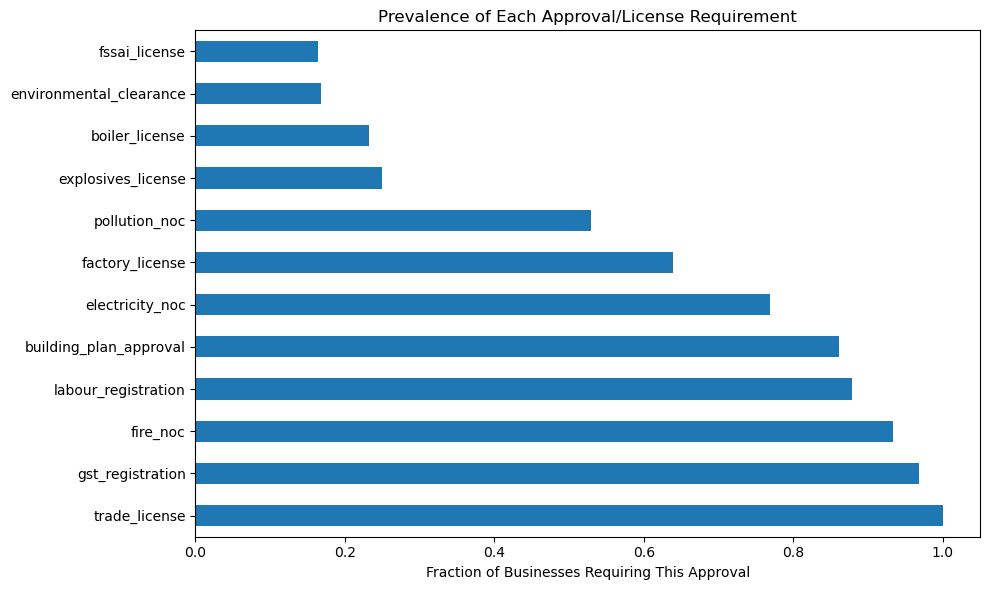

In [7]:
plt.figure(figsize=(10, 6))
label_prevalence.plot(kind='barh')
plt.title('Prevalence of Each Approval/License Requirement')
plt.xlabel('Fraction of Businesses Requiring This Approval')
plt.tight_layout()
plt.show()

## 4. Preprocessing — ColumnTransformer (same pattern as Global Disaster ANN)

In [8]:
categorical_cols = ['district', 'sector']
numeric_cols = ['investment_lakhs', 'employee_count', 'power_requirement_kw',
                 'land_area_sqm', 'water_usage_kld']
binary_cols = ['uses_hazardous_material', 'uses_boiler', 'is_service_sector']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('bin', 'passthrough', binary_cols)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# OneHotEncoder may return a sparse matrix
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

input_dim = X_train_processed.shape[1]
output_dim = y_train.shape[1]

print("Input dimension:", input_dim)
print("Output dimension (number of licenses):", output_dim)

Input dimension: 38
Output dimension (number of licenses): 12


## 5. Build ANN — Multi-Label Classification

Same Dense-stack architecture pattern as the Global Disaster / COVID ANN projects, but:
- Output layer uses **sigmoid** (not linear) since we need independent 0-1 probabilities per label
- Loss is **binary_crossentropy** (not MAE) since this is classification, not regression
- Each of the 12 output nodes is an independent yes/no prediction — a business can require several approvals simultaneously

In [10]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(output_dim, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           9,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,916 (202.80 KB)

 Trainable params: 51,916 (202.80 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train_processed, y_train.values,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8346 - loss: 0.4090 - val_binary_accuracy: 0.9037 - val_loss: 0.2677
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9125 - loss: 0.2420 - val_binary_accuracy: 0.9279 - val_loss: 0.2121
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9249 - loss: 0.2119 - val_binary_accuracy: 0.9364 - val_loss: 0.1920
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9311 - loss: 0.1965 - val_binary_accuracy: 0.9372 - val_loss: 0.1816
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9361 - loss: 0.1863 - val_binary_accuracy: 0.9404 - val_loss: 0.1746
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9387 - loss: 0.1798 - val_binary_accuracy: 0.9479 - val_loss: 0.1652
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9405 - loss: 0.1726 - val_binary_accuracy: 0.9477 - val_loss: 0.1635
Epoch 8/50
85/85 ━━━

 1/85 ━━━━━━━━━━━━━━━━━━━━ 1:56 1s/step - binary_accuracy: 0.4427 - loss: 0.7151

27/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7729 - loss: 0.5384 

54/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8149 - loss: 0.4525

81/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8382 - loss: 0.4024

...

 1/85 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - binary_accuracy: 0.9596 - loss: 0.1378

28/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9660 - loss: 0.1148 

55/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9670 - loss: 0.1126

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9669 - loss: 0.1133

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9668 - loss: 0.1136 - val_binary_accuracy: 0.9667 - val_loss: 0.1279


## 7. Training History Plots

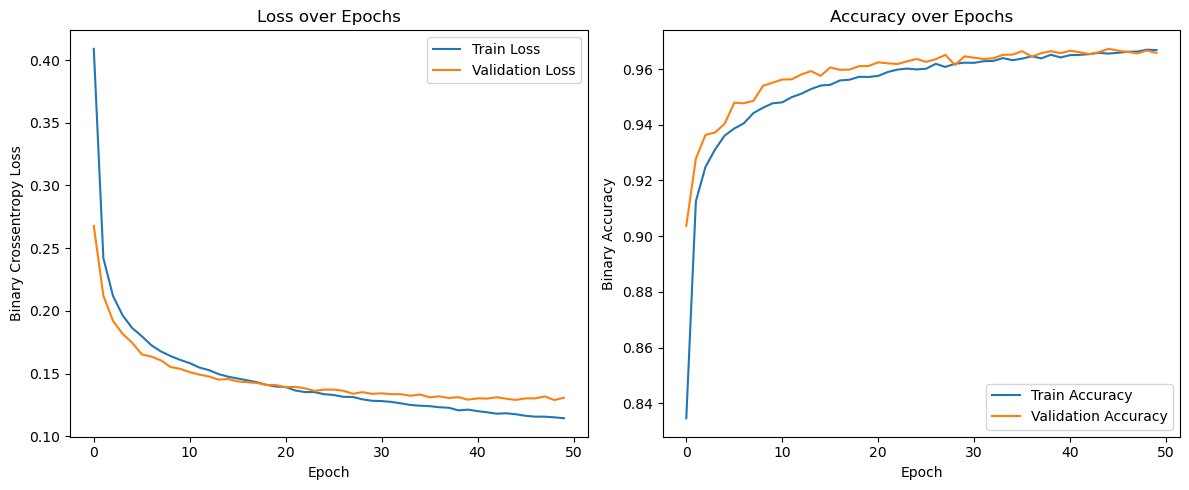

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [13]:
loss, binary_acc = model.evaluate(X_test_processed, y_test.values, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Binary Accuracy: {binary_acc:.4f}")

Test Loss: 0.1369
Test Binary Accuracy: 0.9649


In [14]:
y_pred_proba = model.predict(X_test_processed)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test.values, y_pred, target_names=target_cols, zero_division=0))

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step
                         precision    recall  f1-score   support

          trade_license       1.00      1.00      1.00      1600
       gst_registration       0.97      1.00      0.98      1546
        factory_license       0.93      0.98      0.95      1013
    labour_registration       0.95      0.99      0.97      1387
               fire_noc       0.96      0.99      0.97      1489
          pollution_noc       0.97      0.95      0.96       849
environmental_clearance       0.94      0.78      0.85       240
          fssai_license       1.00      1.00      1.00       262
         boiler_license       1.00      1.00      1.00       380
     explosives_license       0.88      0.90      0.89       398
        electricity_noc       0.95      0.98      0.97      1199
 building_plan_approval       0.96      0.99      0.98      1351

              micro avg       0.96      0.98      0.97     11714
              macro avg       0.96      0.96   

48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


                         precision    recall  f1-score   support

          trade_license       1.00      1.00      1.00      1600
       gst_registration       0.97      1.00      0.98      1546
        factory_license       0.94      0.97      0.96      1013
    labour_registration       0.96      0.98      0.97      1387
               fire_noc       0.96      1.00      0.98      1489
          pollution_noc       0.97      0.96      0.96       849
environmental_clearance       0.92      0.78      0.84       240
          fssai_license       1.00      1.00      1.00       262
         boiler_license       1.00      1.00      1.00       380
     explosives_license       0.89      0.89      0.89       398
        electricity_noc       0.96      0.97      0.97      1199
 building_plan_approval       0.96      0.99      0.97      1351

              micro avg       0.96      0.98      0.97     11714
              macro avg       0.96      0.96      0.96     11714
           weighted avg

## 9. Sample Prediction — Sanity Check

In [15]:
sample = X_test.iloc[[0]]
sample_processed = preprocessor.transform(sample)
if hasattr(sample_processed, 'toarray'):
    sample_processed = sample_processed.toarray()

sample_pred = model.predict(sample_processed)[0]

print("Sample business profile:")
print(sample)
print()
print("Predicted approvals required:")
for label, prob in zip(target_cols, sample_pred):
    status = "REQUIRED" if prob > 0.5 else "not required"
    print(f"  {label:28s} -> {status:14s} (confidence: {prob*100:.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Sample business profile:
     district                         sector  investment_lakhs  \
2215  Patiala  Engineering/Metal Fabrication             225.3   

      employee_count  power_requirement_kw  land_area_sqm  water_usage_kld  \
2215               5                  25.8          906.5              6.0   

      uses_hazardous_material  uses_boiler  is_service_sector  
2215                        0            0                  0  

Predicted approvals required:
  trade_license                -> REQUIRED       (confidence: 100.0%)
  gst_registration             -> REQUIRED       (confidence: 94.4%)
  factory_license              -> not required   (confidence: 2.9%)
  labour_registration          -> REQUIRED       (confidence: 52.8%)
  fire_noc                     -> REQUIRED       (confidence: 86.4%)
  pollution_noc                -> not required   (confidence: 0.8%)
  environmental_clearance      -> not required   (confidence: 3.9%)
  fssai

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


Sample business profile:
     district                         sector  investment_lakhs  \
2215  Patiala  Engineering/Metal Fabrication             225.3   

      employee_count  power_requirement_kw  land_area_sqm  water_usage_kld  \
2215               5                  25.8          906.5              6.0   

      uses_hazardous_material  uses_boiler  is_service_sector  
2215                        0            0                  0  

Predicted approvals required:
  trade_license                -> REQUIRED       (confidence: 100.0%)
  gst_registration             -> REQUIRED       (confidence: 92.4%)
  factory_license              -> not required   (confidence: 2.7%)
  labour_registration          -> REQUIRED       (confidence: 57.3%)
  fire_noc                     -> REQUIRED       (confidence: 92.9%)
  pollution_noc                -> not required   (confidence: 0.6%)
  environmental_clearance      -> not required   (confidence: 5.1%)
  fssai_license                -> not require

## 10. Save Model, Preprocessor, and Metadata

These saved files are loaded by the Flask backend (`api.py`), which powers `index.html`.

In [16]:
model.save('udyamflow_ann_model.keras')
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(target_cols, 'target_cols.pkl')
joblib.dump(
    {'districts': sorted(df['district'].unique().tolist()),
     'sectors': sorted(df['sector'].unique().tolist())},
    'category_options.pkl'
)

print("Model, preprocessor, and metadata saved successfully.")

Model, preprocessor, and metadata saved successfully.


## Conclusion

- The ANN achieves strong multi-label classification performance across all 12 approval/license categories.
- Rare labels (e.g. `environmental_clearance`, `explosives_license`) show lower but still reasonable F1-scores — expected given their lower prevalence in the dataset.
- Model is saved and ready to be served via the Flask API (`api.py`) for the `index.html` frontend.